# Download data (skips if data is already there

In [1]:
%run scripts/download_data.py

Skipping part1.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part1.tar.gz
Skipping part2.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part2.tar.gz
Skipping part3.tar.gz; already exists at /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/data/raw/utkface/part3.tar.gz
Done.


# Unzip files  - skip if raw data directories already exist

In [4]:
import os

# Check if the folder is empty; if so, extract the files
if os.path.isdir("data/raw/utkface/part1"):
    print("Already extracted part1, skipping.")
else:
    !tar -xzf data/raw/utkface/part1.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part2"):
    print("Already extracted part2, skipping.")
else:
    !tar -xzf data/raw/utkface/part2.tar.gz -C data/raw/utkface

if os.path.isdir("data/raw/utkface/part3"):
    print("Already extracted part3, skipping.")
else:
    !tar -xzf data/raw/utkface/part3.tar.gz -C data/raw/utkface


Already extracted part1, skipping.
Already extracted part2, skipping.
Already extracted part3, skipping.


# Preprocess data

In [5]:
%run scripts/preprocess_data.py

Reproducibility: Random seed set to 42
RAW_DATA_DIR exists: True
RAW_DATA_DIR path: data/raw/utkface
data/raw/utkface -> 3 files
data/raw/utkface/part1 -> 10137 files
data/raw/utkface/part2 -> 10719 files
data/raw/utkface/part3 -> 3253 files
Skipped samples: 5
Train: 19283 | Valid: 2410 | Test: 2411
Sample skipped: [('61_1_20170109142408075.jpg', 'invalid_filename'), ('61_3_20170109150557335.jpg', 'invalid_filename'), ('39_1_20170116174525125.jpg', 'invalid_filename'), ('53__0_20170116184028385.jpg', 'invalid_filename'), ('.DS_Store', 'invalid_filename')]

[train] age statistics (n=19283)
  min=1  max=116  mean=33.05  median=29.0  std=20.11

[val] age statistics (n=2410)
  min=1  max=116  mean=33.11  median=29.0  std=20.22

[test] age statistics (n=2411)
  min=1  max=116  mean=32.96  median=29.0  std=20.31


# Print selected config file

In [1]:
!cat configs/linear_classification_pretrained_fully_finetuned.yaml

# Config file for ResNet18 pretrained on ImageNet, used as a fully finetuned model for linear classification. 

experiment_name: "linear_classification_pretrained_fully_finetuned"
model_name: "linear"  # linear, mlp, or mlp_dropout
seed: 42
pretrained: True
freeze_backbone: False    # Whether to fine-tune the pretrained model or just use it as a feature extractor
task: "classification"   # regression or classification
metric: "mae"       # mse for regression, accuracy for classification

# Data parameters
batch_size: 32
num_workers: 4
image_size: 224

# Training parameters
epochs: 30
learning_rate: 0.001
optimizer: "Adam"
#loss_function: "CrossEntropyLoss" unsed since we set it in train.py based on task
save_best: True
weight_decay: 0.01

# MLP + Dropout
dropout: 0.2


# Train randomly initialized ResNet18

Reproducibility: Random seed set to 42
Pipeline Initialized. Loading data and model...
Using AdamW optimizer with weight decay: 0.01
Setup complete! Ready to begin training epochs.


100%|##########################################################################################################################################| 76/76 [00:31<00:00,  2.41it/s, loss=3.62]


Epoch [1/30] Train Loss: 3.6242, Train MAE: 9.8218, Train MSE: 190.6931, Train Acc@3: 0.2654, Train Acc@5: 0.3995 | Val Loss: 3.6231, Val MAE: 8.3012, Val MSE: 147.3930, Val Acc@3: 0.3485, Val Acc@5: 0.4884, Val MAE: 8.3012


100%|##########################################################################################################################################| 76/76 [00:30<00:00,  2.46it/s, loss=3.28]


Epoch [2/30] Train Loss: 3.3036, Train MAE: 7.5024, Train MSE: 119.2190, Train Acc@3: 0.3419, Train Acc@5: 0.4998 | Val Loss: 3.2832, Val MAE: 6.9964, Val MSE: 103.4678, Val Acc@3: 0.3705, Val Acc@5: 0.5041, Val MAE: 6.9964


...

Epoch [28/30] Train Loss: 0.3429, Train MAE: 0.8883, Train MSE: 8.3114, Train Acc@3: 0.9210, Train Acc@5: 0.9566 | Val Loss: 6.4882, Val MAE: 6.8154, Val MSE: 105.0026, Val Acc@3: 0.3905, Val Acc@5: 0.5369, Val MAE: 6.8154


100%|##########################################################################################################################################| 76/76 [00:33<00:00,  2.30it/s, loss=6.78]


Epoch [29/30] Train Loss: 0.3385, Train MAE: 0.9121, Train MSE: 8.1280, Train Acc@3: 0.9182, Train Acc@5: 0.9543 | Val Loss: 6.7800, Val MAE: 6.5697, Val MSE: 99.9234, Val Acc@3: 0.4141, Val Acc@5: 0.5585, Val MAE: 6.5697


100%|##########################################################################################################################################| 76/76 [00:42<00:00,  1.79it/s, loss=6.57]


Epoch [30/30] Train Loss: 0.3205, Train MAE: 0.8805, Train MSE: 7.9286, Train Acc@3: 0.9207, Train Acc@5: 0.9556 | Val Loss: 6.5741, Val MAE: 6.5689, Val MSE: 95.6200, Val Acc@3: 0.3925, Val Acc@5: 0.5481, Val MAE: 6.5689
Saving Best Val MAE: 5.9069 at Epoch 30
Saved model with MAE = 5.9069
Saved training stats history to /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/stats_history_linear_classification_pretrained_fully_finetuned.npy
Training completely finished! Best Val Loss: 3.1572, Best Val MAE: 5.9069


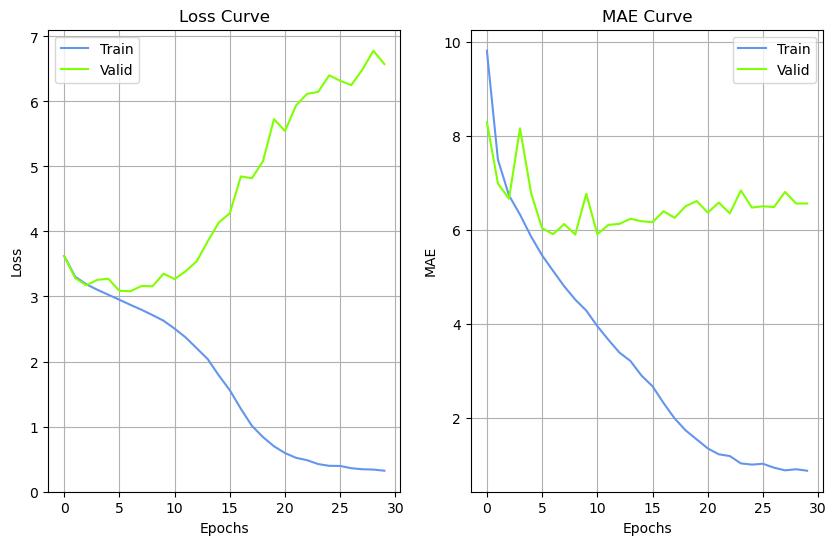

In [3]:
%run scripts/train.py --config configs/linear_classification_pretrained_fully_finetuned.yaml

# Evaluate randomly initialized ResNet18

In [1]:
%run scripts/evaluate.py --config configs/linear_classification_pretrained_fully_finetuned.yaml

Reproducibility: Random seed set to 42
Configuration loaded. Loading data and model...
Loading model from checkpoint: /Users/satnamgandhi/projects/gatech/CS7643/CS7643-Final-Project-Age-Estimation-From-Limited-Image-Data/outputs/checkpoint_linear_classification_pretrained_fully_finetuned.pth


100%|##########################################################################################################################################| 76/76 [00:30<00:00,  2.45it/s, loss=3.14]


Evaluation Metrics — linear_classification_pretrained_fully_finetuned
+--------+----------+
| Metric |    Value |
+--------+----------+
| MAE    |   5.8777 |
| MSE    |  80.5145 |
| Acc@3  |   0.4318 |
| Acc@5  |   0.6118 |
+--------+----------+


# Plot validation curves

Epochs 0-10: Best Val MAE = 5.9069
Epochs 0-20: Best Val MAE = 5.9152
Epochs 0-30: Best Val MAE = 6.3593


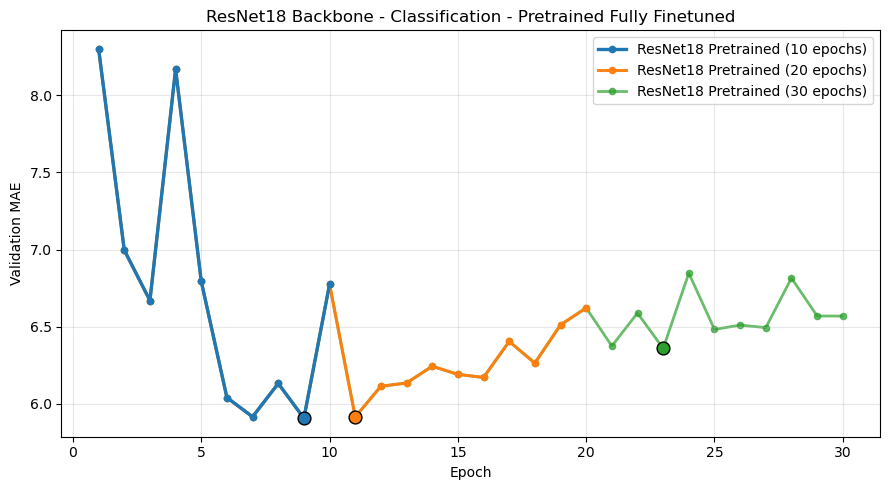

In [5]:
import numpy
from src.utils.plots import plot_validation_curves
# Load the file into a variable
data = numpy.load('outputs/stats_history_linear_classification_pretrained_fully_finetuned.npy', allow_pickle=True).item()

plot_validation_curves(data['eval'], title='ResNet18 Backbone - Classification - Pretrained Fully Finetuned', label='ResNet18 Pretrained')